In [1]:
import numpy as np
from matplotlib import pyplot as plt
import sys
sys.path.append('../../SI-Figures/')
from myutils.process_AD import readResT_from_NERDSS

In [2]:
def onRate_macro2micro(ka_macro, D, sigma):
    if ka_macro < 1e-10:
        return 0
    else:
        return (1/ka_macro - 1/(4*np.pi*D*sigma))**-1

We perform spatial single-molecule simulations to quantify the dwell time of monomers, reversible dimers, and irreversible dimers binding nonspecific sites on DNA. Since the diffusion effect is hard to be captured in non-spatial models in 1D, for future generalization, we set our system at rate limit, $k_a << 4\pi D_{3D}\sigma$, where $k_a$ is the 3D microscopic association rate, $D_{3D}$ is the 3D diffusion constant, and $\sigma$ is the reaction radius. Here we choose $D_{3D} = 1.5\ \mu m^2 / s$ for protein monomers in nucleoplasm. For protein dimerization, P+P<->P_2, $\sigma=2\ nm$ and for protein binding nonspecific sites on DNA, $\sigma=1\ nm$. Once a protein monomer binds on DNA, its 1D diffusion constant is $D_{1D} = 0.6\ \mu m^2 / s$, which is at the upper limit of diffusion along DNA for our rate-limited assertion. We fix the protein dimerization strength to be $K_{A}^P = 10^6 M^{-1}$. We report all rates in 3D macroscopic manner ($k_{on}$ and $k_{off}$) and the microscopic rates used in NERDSS simulations are calculated as following:
$$
\frac{1}{k_a} = \frac{1}{k_{on}} - \frac{1}{4\pi D_{3D}\sigma} \\
k_b = k_a / K_A
$$
To capture the dimensionality effecy, we set $h^2=114\ nm^2$.

$N_N = 240$ and $N_P=2$ proteins nonspecific sites are randmly initialized in the system with L = 420 nm, and Ly=Lz=31.623 nm.

From Szabo's FPT theory, the association rate of PPN to N should be adjusted by ($b = L/(N_N-1)\approx1.75$):
$$
\frac{1}{k_{on}} = \frac{1}{k_a^N} + \frac{b-\sigma}{3D_{tot}}.
$$
Since the diffusion constant of N and PPN are $D_N=1\ \mu m^2 / s$ and $D_{PPN}=0.4286\ \mu m^2 / s$, respectively, we have $D_{tot}=1.4286\ \mu m^2 / s$
$$
k_{on} = \frac{k_a/h^2}{0.175 \cdot 0.0002/114 + 1} \approx \frac{k_a}{h^2}
$$

A more conserved limit for rate-limit reaction is $k_a \ll 3D/L$. For PPN + N, $D_{tot}=1.4286\ \mu nm^2 / \mu s$ and $L=420\ nm$, thus $3D/L=0.01\ nm / \mu s$. We use $k_a = 0.0002/114 \approx 1.75 \times 10^{-6}\ nm / \mu s$ that also fulfills the requirement of $k_a << 3D/L$.

From our model, the irreversible dimer's dwell time should be 
$$\left(1 + \frac{\gamma K_A^N\cdot [N]_{tot}}{2}\right)\cdot \tau_N,$$
which is an enhancement of a factor of $1.832$

In [74]:
1.75/3/1.4286

0.40832516682999676

In [5]:
# for P+P
DPP = 1.5 * 2
sigmaPP = 2
KPP = 1e6 / 0.6022
# for P+N
DPN = 1.5
sigmaPN = 1
KPN = 200 / 0.6022
# kinetic rates for PN
kon = 200 * 1e-6
ka = onRate_macro2micro(kon, DPN, sigmaPN)
print('kaN = %.8f and kbN = %.4f'%tuple(np.round((ka, ka/KPN * 1e6), 4)))

kaN = 0.00020000 and kbN = 0.6022


In [53]:
2/(420*1000)/0.6022, 240/(420*1000)

(7.907513719536304e-06, 0.0005714285714285715)

In [54]:
20/(1050*1000)/0.6022, 600/(1050*1000)

(3.1630054878145214e-05, 0.0005714285714285715)

In [6]:
kon = 0.1
ka = onRate_macro2micro(kon, DPP, sigmaPP)
print('kaP = %.4f and kbP = %.4f'%tuple(np.round((ka, ka/KPP * 1e6), 4)))

kaP = 0.1001 and kbP = 0.0603


In [7]:
kon = 1
ka = onRate_macro2micro(kon, DPP, sigmaPP)
print('kaP = %.4f and kbP = %.4f'%tuple(np.round((ka, ka/KPP * 1e6), 4)))

kaP = 1.0134 and kbP = 0.6103


In [8]:
kon = 10
ka = onRate_macro2micro(kon, DPP, sigmaPP)
print('kaP = %.4f and kbP = %.4f'%tuple(np.round((ka, ka/KPP * 1e6), 4)))

kaP = 11.5291 and kbP = 6.9428


In [3]:
from scipy.optimize import curve_fit

def get_survival_prob(resident_times, bins=100):

    # get survival probabilities
    h = np.histogram(resident_times, bins=bins, density=True)
    return h[1], np.append([1], 1 - np.cumsum(h[0]*np.diff(h[1])))

def bootstrapSurvProb(
    resTime_nerdss, timeUpperLimit, binwidth, N_batch=100, survP_thres=1e-1,
    fittingTarget = 'single'
):
    tbins=np.arange(0, timeUpperLimit, binwidth)
    N_sample = len(resTime_nerdss)
    # print(N_sample, batchSize)
    survprobList = [] # for survial probabilities
    fitted_tau_list = [] # for fitted tau
    mean_list = [] # for direct mean value
    for _ in range(N_batch):
        randomChoices = np.random.choice(resTime_nerdss, size=N_sample, replace=True)
        mean_list.append(np.mean(randomChoices))
        
        time, survP = get_survival_prob(randomChoices, tbins)
        survprobList.append(survP)
        
        survpFilter = survP > survP_thres
        
        # exponential decay y = e^(-t/tau)
        if fittingTarget == 'single':
            popt, pcov = curve_fit(
                lambda t, tau: np.exp(-t/tau), 
                time[survpFilter], survP[survpFilter], 
                bounds=(0, np.inf)
            )
            fitted_tau_list.append(popt[0])
        # double exponential decay y = f*e^(-t/tau1) + (1-f)e^(-t/tau2)
        elif fittingTarget == 'double':
            tauN0 = 1 / 0.6022
            p0 = [tauN0, tauN0, 0.9]
            popt, pcov = curve_fit(
                lambda t, tau1, tau2, f: f*np.exp(-t/tau1) + (1-f)*np.exp(-t/tau2), 
                time[survpFilter], survP[survpFilter], p0=p0,
                bounds=([0,0,0], [np.inf, np.inf, 1])
            )
            tau1, tau2, f = popt
            fitted_tau_list.append( f*tau1 + (1-f)*tau2 )
        elif fittingTarget == 'none':
            pass
    return time, survprobList, fitted_tau_list, mean_list

# Initial try

- Since the accurate collection of survival probability requires long simulations. It might be better to fit the survival probability with single exponential decay (similar to calculating the mean residence time).
- Now we ignore proteins that are still bound when simulation ends. However, if the number of dissociation events $N_{diss}$ is not large enough, the proteins remain bound may meaningfully shift the result. Therefore, for $N_{diss} > 100 \times N_P$, even boldly speeking, wee can only trust the survival probability $P_{surv}>0.01$. To assess rare events like $P_{surv} \in (0.001, 0.01)$, we at least need $N_{diss} > 1000 \times N_P$.

In [57]:
NerdssRepeatIDs = [i for i in range(48)]
dt = 1e-6
startT = 10

subdir_list = ['kpp1E6koffP10', 'kpp1E6koffP1', 'kpp1E6koffP01', 'dimer', 'monomer']
resT_list = []
for subdir in subdir_list:
    resTs = []
    for i in NerdssRepeatIDs:
        jobfolder = f'./1DNA/{subdir}/nerdss_output/{i}'
        resTi, _ = readResT_from_NERDSS(
            jobfolder+'/DATA/assoc_dissoc_time.dat', dt, startT=startT
        )
        resTs.append(resTi)
    resT_list.append(resTs)
    
# kbN = 0.6022
print([np.round(np.mean(np.concatenate(resTs)),3) for resTs in resT_list])
print([np.round(np.std(np.concatenate(resTs)),4) for resTs in resT_list])

[1.062, 1.26, 1.747, 1.65, 1.635]
[1.5112, 1.4496, 1.8334, 1.6782, 1.6538]


In [68]:
survP_thres = 0.1
fittingTarget = 'single'

print('\nrelative dwell times:')
mean_rel_dwell = []
for i, resTs in enumerate(resT_list[:]):
    print(subdir_list[i])
    print('  Number of dissociation evvents per monomer:', 
          round(np.mean([len(resT)/2 for resT in resTs])))
    _, _, fit_list, mean_list = bootstrapSurvProb(
        np.concatenate(resTs), 100, 0.1, survP_thres=survP_thres,
        fittingTarget=fittingTarget
    )
#     mean_rel_dwell.append(np.mean(tau_list)/mon_mean)
    print(f'Fit S=exp(-t/tau) (S>0.1): {np.mean(fit_list):.3f} +- {np.std(fit_list):.4f}')
    print(f'        Simple mean value: {np.mean(mean_list):.3f} +- {np.std(mean_list):.4f}')


relative dwell times:
kpp1E6koffP10
  Number of dissociation evvents per monomer: 144
Fit S=exp(-t/tau) (S>0.1): 0.919 +- 0.0141
        Simple mean value: 1.062 +- 0.0129
kpp1E6koffP1
  Number of dissociation evvents per monomer: 187
Fit S=exp(-t/tau) (S>0.1): 1.184 +- 0.0118
        Simple mean value: 1.260 +- 0.0116
kpp1E6koffP01
  Number of dissociation evvents per monomer: 142
Fit S=exp(-t/tau) (S>0.1): 1.709 +- 0.0150
        Simple mean value: 1.747 +- 0.0143
dimer
  Number of dissociation evvents per monomer: 81
Fit S=exp(-t/tau) (S>0.1): 1.633 +- 0.0191
        Simple mean value: 1.651 +- 0.0185
monomer
  Number of dissociation evvents per monomer: 87
Fit S=exp(-t/tau) (S>0.1): 1.631 +- 0.0199
        Simple mean value: 1.634 +- 0.0174


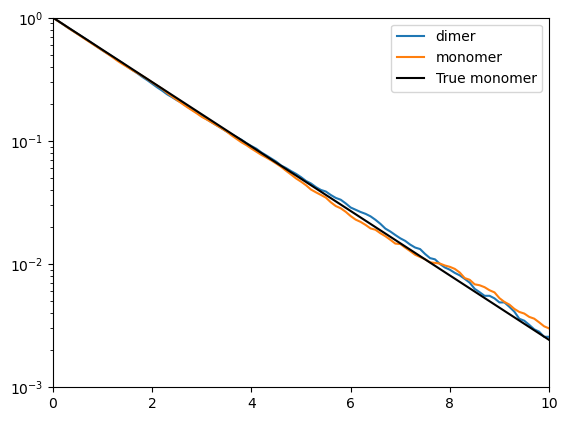

In [65]:
# fig, axes = plt.subplots(2, 2)
# plot_pos = [[0,0], [0,1], [1,0], [1,1]]
t_max = 100
t_binWidt = 0.1
labels = ['dimer', 'monomer']
for i, resTs in enumerate(resT_list[3:]):
    plt.semilogy(
        *get_survival_prob(np.concatenate(resTs), 
                           bins=np.arange(0, t_max, t_binWidt)),
        label=labels[i]
    )
tspan = np.linspace(0,10)
plt.plot(tspan, np.exp(-tspan*0.6022), color='black', label='True monomer')

plt.ylim([1e-3,1])
plt.xlim([0,min(10, t_max)])
plt.legend()

In [45]:
NerdssRepeatIDs = [1,2,3]
dt = 1e-6
startT = 1e2

# As a mistake, the monomer simulation has kbN = 1.6606
subdir_list = ['monomer']
resT_list = []
for subdir in subdir_list:
    resTs = []
    for i in NerdssRepeatIDs:
        jobfolder = f'./{subdir}/nerdss_output/{i}'
        resTi, _ = readResT_from_NERDSS(
            jobfolder+'/DATA/assoc_dissoc_time.dat', dt, startT=startT
        )
        resTs.append(resTi)
    resT_list.append(resTs)
    
# kbN = 0.6022
[np.mean(np.concatenate(resTs))*1.6606 for resTs in resT_list]

[0.9787176307253868]

# Compare with Gillespie

Since solving mean dwell time from NERDSS simulation does not work, I will try compare it with Gillespie simulations. First, I need to run Gillespie simulations to see if they reach correct results.

Here we can directly use the same parameters for ODE solutions.

In [110]:
# Run this cell for new simulations for equilibrium
import pandas as pd
sys.path.append('../../')
from odeSolver.Nonly import rxnNetwork, labels
from odeSolver.main import main as numericSolver
# for generating parameters
from GenerateParameters import GenParameters

GenParms = lambda kbP :GenParameters(
    ifwrite=False, numTargets=0, kbPP_fixed=kbP,   
    KPN=[200], NP0=[0.1], area3Dto1D=[114],
    KPP=[1e6], 
)

parm_num = pd.concat([GenParms(0.1), GenParms(1), GenParms(10)], axis=0, ignore_index=True)
for i, row in parm_num.iterrows():
    parm_num.loc[i,'ID'] = int(i)
equi_num = numericSolver(parm_df=parm_num, labels=labels, model=rxnNetwork)

from pathlib import Path

pfolder_Gillespie = './Gillespie/'

Path(pfolder_Gillespie).mkdir(parents=True, exist_ok=True)
parm_num.to_csv(pfolder_Gillespie+'/parameters.csv')
equi_num.to_csv(pfolder_Gillespie+'/equilibrium.csv')

2025-10-15 20:22:05.514223
Number of cores used:  3/36
Finished parallel processing.


In [4]:
def readGillespieSurvP(filename):
    # No estimation of standard error since it is a single experiment
    with open(filename) as f:
        reading = False
        times = []
        survP = []
        numDiss = 'Not Read'
        for line in f:
            if line.strip() == '# START SURVIVAL PROB':
                reading = True
            elif line.strip() == '# END SURVIVAL PROB':
                reading = False
            elif line.strip() == '# Mean Residence Time':
                meanResT = float(f.readline().strip())
            elif line.strip().startswith('Number of dissociation events:'):
                numDiss = int(line.split(':')[1])
            else:
                if reading:
                    linelist = line.split()
                    times.append(float(linelist[0]))
                    survP.append(float(linelist[1]))
    return np.array(times), np.array(survP), meanResT, numDiss

kpp1E6koffP10
Average dissociation events: 144
kpp1E6koffP1
Average dissociation events: 187
kpp1E6koffP01
Average dissociation events: 142


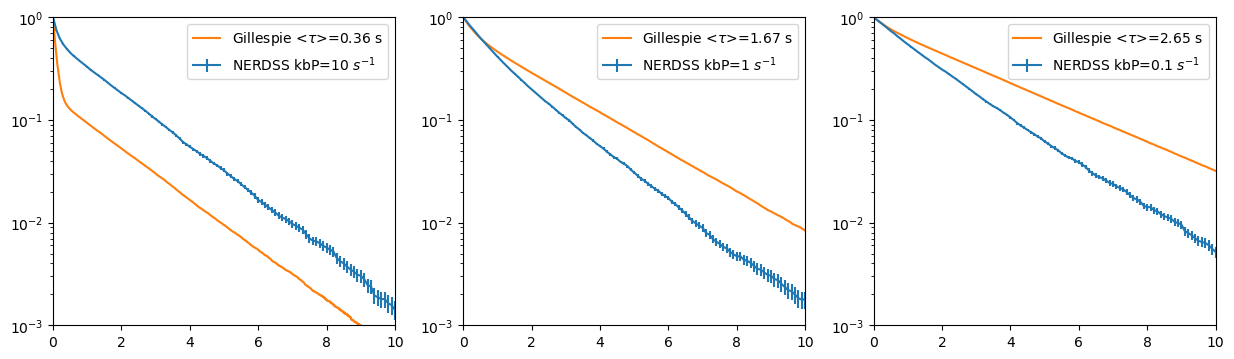

In [11]:
NerdssRepeatIDs = [i for i in range(48)]
dt = 1e-6
startT = 10

t_max = 100
t_binWidth = 0.1
survP_thres = 0.1

subdir_list = ['kpp1E6koffP10', 'kpp1E6koffP1', 'kpp1E6koffP01']
kpoff_list = [10, 1, 0.1]
gillespie_files = ['out_2_r0', 'out_1_r0', 'out_0_r0']


plt.figure(figsize=(15,4))
for j, subdir in enumerate(subdir_list):
    plt.subplot(1,3,j+1)
    resTs = []
    for i in NerdssRepeatIDs:
        jobfolder = f'./{subdir}/nerdss_output/{i}'
        resTi, _ = readResT_from_NERDSS(
            jobfolder+'/DATA/assoc_dissoc_time.dat', dt, startT=startT
        )
        resTs.append(resTi)
    resTs = np.concatenate(resTs)
    
    print(subdir)
    print('Average dissociation events:', round(len(resTs)/2/48))
    
    gllspFile = f'./Gillespie/OUTPUTS_Nonly/{gillespie_files[j]}'
    timeGllsp, survPGllsp, meanRestGllsp, numEvents = readGillespieSurvP(gllspFile)
    
    time, survprobList, _, _ = bootstrapSurvProb(
        resTs, t_max, t_binWidth, N_batch=100, survP_thres=survP_thres,
        fittingTarget = 'none'
    )
    plt.errorbar(
        time, np.mean(survprobList, axis=0), np.std(survprobList, axis=0), 
        label=f'NERDSS kbP={kpoff_list[j]}'+' $s^{-1}$'
    )
    
    plt.semilogy(
        timeGllsp, survPGllsp, label=f'Gillespie <$\\tau$>={meanRestGllsp:.2f} s'
    )
    
    plt.ylim([1e-3,1])
    plt.xlim([0,min(10, t_max)])
    plt.legend()
plt.show()
    


# more DNA molecules

It is very possible that currently, the state change of a monomer can shift the system away from equilibrium too much. The near-equilibrium system used in Gillespie simulations is (Totally 200 proteins):
```
P: 33, PP: 47, PN: 7, PPN: 18, PNPN: 15
```
This is 40 monomers ~ 80 dimers. In this case, 2 proteins is far from enough. To get a near-equilibrium system, 20 proteins might be enough. In our setup, one way to include more proteins is to have more DNA molecules (like 4, 9, 16, etc). Let's do 16!

In [162]:
def generate_molecule_coordinates(Lx, Ly, Lz, num_x, num_y_lines, num_z_lines):
    """
    Generates a PDB file string for molecules placed on a grid of lines.

    Args:
        Lx (float): Box dimension in the x-direction.
        Ly (float): Box dimension in the y-direction.
        Lz (float): Box dimension in the z-direction.
        num_x (int): Number of molecules to place along each line (x-axis).
        num_y_lines (int): Number of lines to create along the y-axis.
        num_z_lines (int): Number of lines to create along the z-axis.

    Returns:
        str: A string containing the molecule coordinates in PDB format.
    """
    # Generate coordinates for the molecules along a single line (x-axis)
    # A small delta is used to avoid placing molecules exactly on the boundary
    delta = 0.001
    x_coords = np.linspace(-Lx/2 + delta, Lx/2 - delta, num_x)

    # Generate the y and z coordinates for the grid of lines
    # The lines are placed at multiples of 1/5th of the box dimension
    y_lines = np.linspace(Ly / 5, (num_y_lines / 5) * Ly, num_y_lines) - Ly/2
    z_lines = np.linspace(Lz / 5, (num_z_lines / 5) * Lz, num_z_lines) - Lz/2

    pdb_lines = []
    atom_index = 1

    # Iterate over the grid of lines (in the y-z plane)
    for z in z_lines:
        for y in y_lines:
            # For each line, place the specified number of molecules along the x-axis
            for x in x_coords:
                # Format the coordinates into a PDB ATOM record.
                # This format specifies atom index, name, residue name, chain,
                # residue index, coordinates (X, Y, Z), and element symbol.
                pdb_line = (
                    f"ATOM  {atom_index:>5d}  COM   N _{atom_index:>4d}    "
                    f"{x:8.3f}{y:8.3f}{z:8.3f} \n"
                )
                pdb_lines.append(pdb_line)
                atom_index += 1

    return "".join(pdb_lines)

In [175]:
Lx = 420
Ly = 31.623*4
Lz = 31.623*4
numN_eachDNA = 240
fixCrds = generate_molecule_coordinates(Lx, Ly, Lz, numN_eachDNA, 4, 4)
with open('./16DNA/fixCoordinates.pdb', 'w') as f:
    f.write(fixCrds)

In [69]:
NerdssRepeatIDs = [i for i in range(48)]
dt = 1e-6
startT = 10

subdir_list = ['kpp1E6koffP10', 'kpp1E6koffP1', 'kpp1E6koffP01', 'dimer']
resT_list = []
for subdir in subdir_list:
    resTs = []
    for i in NerdssRepeatIDs:
        jobfolder = f'./16DNA/{subdir}/nerdss_output/{i}'
        resTi, _ = readResT_from_NERDSS(
            jobfolder+'/DATA/assoc_dissoc_time.dat', dt, startT=startT
        )
        resTs.append(resTi)
    resT_list.append(resTs)
    
# kbN = 0.6022
print([np.round(np.mean(np.concatenate(resTs))*0.6022,3) for resTs in resT_list])
print([np.round(np.std(np.concatenate(resTs))*0.6022,4) for resTs in resT_list])

[0.454, 0.677, 0.947, 0.943]
[0.6749, 0.7395, 0.9489, 0.9282]


In [70]:
survP_thres = 0.5
fittingTarget = 'single'

print('\nrelative dwell times:')
mean_rel_dwell = []
for i, resTs in enumerate(resT_list[:]):
    print(subdir_list[i])
    print('  Number of dissociation evvents per monomer:', 
          round(np.mean([len(resT)/2 for resT in resTs])))
    _, _, fit_list, mean_list = bootstrapSurvProb(
        np.concatenate(resTs), 100, 0.1, survP_thres=survP_thres,
        fittingTarget=fittingTarget
    )
#     mean_rel_dwell.append(np.mean(tau_list)/mon_mean)
    print(f'Fit S=exp(-t/tau) (S>0.1): {np.mean(fit_list):.3f} +- {np.std(fit_list):.4f}')
    print(f'        Simple mean value: {np.mean(mean_list):.3f} +- {np.std(mean_list):.4f}')


relative dwell times:
kpp1E6koffP10
  Number of dissociation evvents per monomer: 29
Fit S=exp(-t/tau) (S>0.1): 0.308 +- 0.0078
        Simple mean value: 0.754 +- 0.0196
kpp1E6koffP1
  Number of dissociation evvents per monomer: 30
Fit S=exp(-t/tau) (S>0.1): 0.988 +- 0.0315
        Simple mean value: 1.125 +- 0.0217
kpp1E6koffP01
  Number of dissociation evvents per monomer: 38
Fit S=exp(-t/tau) (S>0.1): 1.551 +- 0.0420
        Simple mean value: 1.571 +- 0.0282
dimer
  Number of dissociation evvents per monomer: 29
Fit S=exp(-t/tau) (S>0.1): 1.600 +- 0.0447
        Simple mean value: 1.564 +- 0.0310


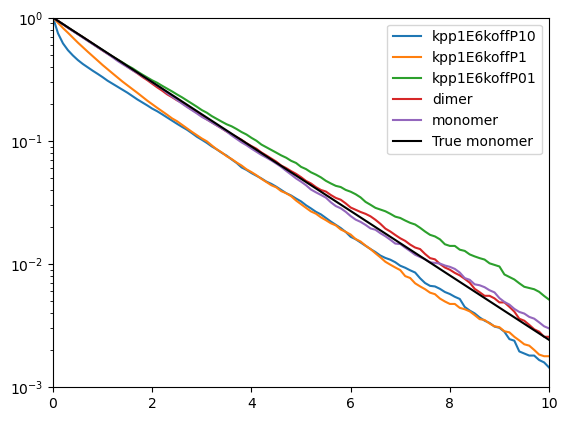

In [66]:
# fig, axes = plt.subplots(2, 2)
# plot_pos = [[0,0], [0,1], [1,0], [1,1]]
t_max = 100
t_binWidt = 0.1
for i, resTs in enumerate(resT_list[:]):
    plt.semilogy(
        *get_survival_prob(np.concatenate(resTs), 
                           bins=np.arange(0, t_max, t_binWidt)),
        label=subdir_list[i]
    )
    
tspan = np.linspace(0,10)
plt.plot(tspan, np.exp(-tspan*0.6022), color='black', label='True monomer')
    
plt.ylim([1e-3,1])
plt.xlim([0,min(10, t_max)])
plt.legend()

kpp1E6koffP10
Average dissociation events: 29
kpp1E6koffP1
Average dissociation events: 30
kpp1E6koffP01
Average dissociation events: 38


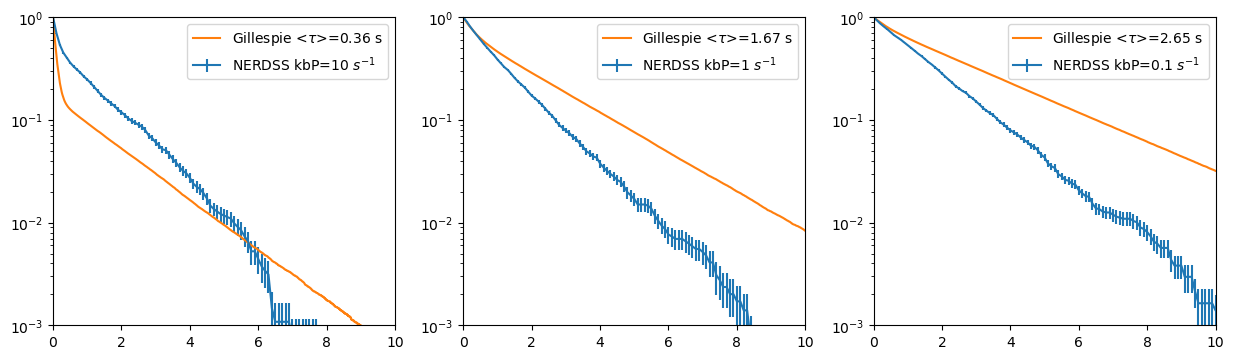

In [9]:
NerdssRepeatIDs = [i for i in range(48)]
dt = 1e-6
startT = 10

t_max = 100
t_binWidth = 0.1
survP_thres = 0.1

subdir_list = ['kpp1E6koffP10', 'kpp1E6koffP1', 'kpp1E6koffP01']
kpoff_list = [10, 1, 0.1]
gillespie_files = ['out_2_r0', 'out_1_r0', 'out_0_r0']


plt.figure(figsize=(15,4))
for j, subdir in enumerate(subdir_list):
    plt.subplot(1,3,j+1)
    resTs = []
    for i in NerdssRepeatIDs:
        jobfolder = f'./16DNA/{subdir}/nerdss_output/{i}'
        resTi, _ = readResT_from_NERDSS(
            jobfolder+'/DATA/assoc_dissoc_time.dat', dt, startT=startT
        )
        resTs.append(resTi)
    resTs = np.concatenate(resTs)
    
    print(subdir)
    print('Average dissociation events:', round(len(resTs)/2/48))
    
    gllspFile = f'./Gillespie/OUTPUTS_Nonly/{gillespie_files[j]}'
    timeGllsp, survPGllsp, meanRestGllsp, numEvents = readGillespieSurvP(gllspFile)
    
    time, survprobList, _, _ = bootstrapSurvProb(
        resTs, t_max, t_binWidth, N_batch=100, survP_thres=survP_thres,
        fittingTarget = 'none'
    )
    plt.errorbar(
        time, np.mean(survprobList, axis=0), np.std(survprobList, axis=0), 
        label=f'NERDSS kbP={kpoff_list[j]}'+' $s^{-1}$'
    )
    
    plt.semilogy(
        timeGllsp, survPGllsp, label=f'Gillespie <$\\tau$>={meanRestGllsp:.2f} s'
    )
    
    plt.ylim([1e-3,1])
    plt.xlim([0,min(10, t_max)])
    plt.legend()
plt.show()
    


# Analyze NERDSS equilibrium

In [37]:
from myutils.nerdssData import nerdssData

In [60]:
NerdssRepeatIDs = [i for i in range(0,48)]
nd = nerdssData(NerdssRepeatIDs, './1DNA/dimer////nerdss_output/')
nd.readHist('DATA/histogram_complexes_time.dat', ifprint=True)

>>>>>> parsing ./1DNA/dimer////nerdss_output/
WaterBox = [420.0, 31.623, 31.623] # VtoL=4000
{'P': 2, 'N': 240}
Reactions:
N(bs) + P(dbn) <-> N(bs!1).P(dbn!1)
P(dmr) + P(dmr) -> P(dmr!1).P(dmr!1)
<<<<<< finished parsing
------------------------------------------------------
Found N: 1. at output 1 (time 0.0 s).
Found P: 1. at output 1 (time 0.0 s).
Found P: 2. at output 2 (time 100.0 s).
Found P: 2. N: 1. at output 9 (time 800.0 s).
Finish read replication 1.
Found N: 1. at output 1 (time 0.0 s).
Found P: 1. at output 1 (time 0.0 s).
Found P: 2. at output 2 (time 100.0 s).
Found P: 2. N: 1. at output 3 (time 200.0 s).
Finish read replication 2.
Found N: 1. at output 1 (time 0.0 s).
Found P: 1. at output 1 (time 0.0 s).
Found P: 2. at output 2 (time 100.0 s).
Found P: 2. N: 1. at output 4 (time 300.0 s).
Finish read replication 3.
Found N: 1. at output 1 (time 0.0 s).
Found P: 1. at output 1 (time 0.0 s).
Found P: 2. at output 2 (time 100.0 s).
Found P: 2. N: 1. at output 7 (time 600.0 

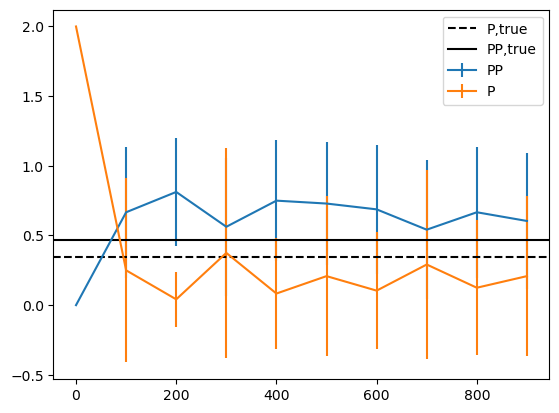

In [54]:
plt.errorbar(nd.time, nd.MOLS['P: 2.'], nd.MOLS_err['P: 2.'], label='PP')
plt.errorbar(nd.time, nd.MOLS['P: 1.'], nd.MOLS_err['P: 1.'], label='P')
plt.axhline(172309/1e6*2, color='black', ls='--', label='P,true')
plt.axhline(234777/1e6*2, color='black', ls='-', label='PP,true')
plt.legend()

# Analyze state transitions PP<-PPN<->PNPN

Since dimer dwell time is totally wrong, here I am going to investigate the inner state transition for a irreversible dimer binding on DNA. The transition rates of PPN -> PP, PPN -> PNPN, and PNPN -> PPN have closed form solutions: $k_{off}^N$, $\gamma\cdot k_{on}^N\cdot [N]=k_{on}^N / h^2\cdot N / L$, and $2\cdot k_{off}^N$.

In [72]:
# PPN -> PNPN
# using units nm and us
konN = 0.000200
lineDensityN = (240-1) / 420 # 1 N already occupied (this influence is minor)
area3Dto1D = 114
print(f'rate: {konN/area3Dto1D * lineDensityN * 1e6} s^-1')

rate: 0.998329156223893 s^-1
